# Titanic Survival Prediction — Logistic Regression from Scratch

**Kaggle competition:** [Titanic - Machine Learning from Disaster](https://www.kaggle.com/c/titanic)

We build logistic regression **from scratch** using the exact same framework from the IIT Madras lecture:

| Component | This notebook |
|---|---|
| **Data** `{x_i, y_i}` | Titanic passenger features → survived (1) / died (0) |
| **Model** `ŷ = σ(w·x + b)` | Sigmoid function |
| **Loss** `L(w,b)` | Binary Cross-Entropy (better than MSE for classification) |
| **Learning Algorithm** | Gradient Descent |

No `sklearn.LogisticRegression` for the core model — we implement every equation by hand.

## 1. Imports & Data

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
np.seterr(all='ignore')   # suppress divide/overflow/invalid from numpy C layer

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# Fetch Titanic dataset directly (no Kaggle account needed)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print(f"Shape: {df.shape}")
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Exploratory Data Analysis

In [2]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nSurvival rate: {df['Survived'].mean():.2%}")
print("\nClass distribution:")
print(df['Survived'].value_counts())

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Survival rate: 38.38%

Class distribution:
Survived
0    549
1    342
Name: count, dtype: int64


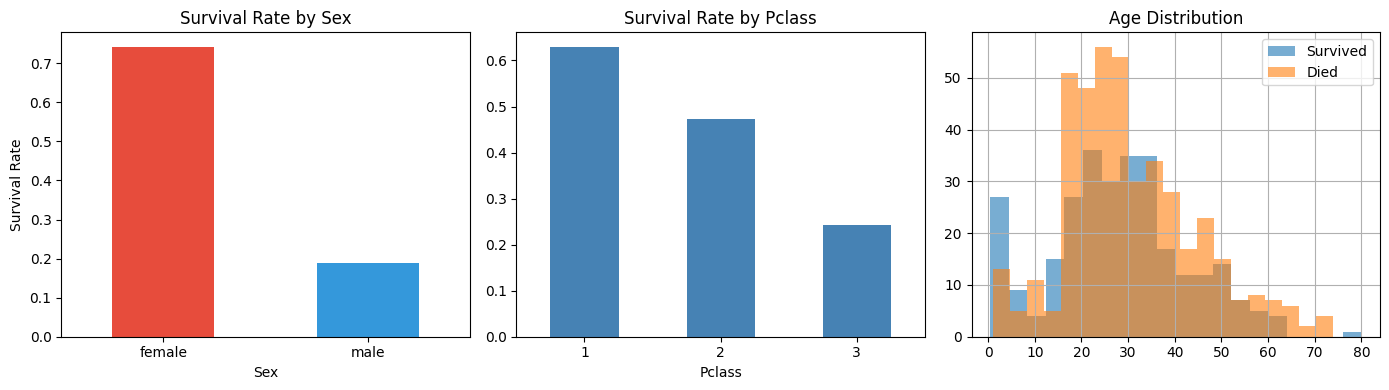

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Survival by sex
df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[0], color=['#e74c3c','#3498db'])
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')
axes[0].tick_params(axis='x', rotation=0)

# Survival by class
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Survival Rate by Pclass')
axes[1].tick_params(axis='x', rotation=0)

# Age distribution
df[df['Survived']==1]['Age'].dropna().hist(ax=axes[2], alpha=0.6, label='Survived', bins=20)
df[df['Survived']==0]['Age'].dropna().hist(ax=axes[2], alpha=0.6, label='Died', bins=20)
axes[2].set_title('Age Distribution')
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Feature Engineering & Preprocessing

We select features that are informative for survival prediction and handle missing values.

In [4]:
df_clean = df.copy()

# Fill missing Age with median, Embarked with mode
df_clean['Age']      = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Encode categorical features
df_clean['Sex_enc']  = (df_clean['Sex'] == 'male').astype(int)       # male=1, female=0
df_clean['Emb_C']    = (df_clean['Embarked'] == 'C').astype(int)
df_clean['Emb_Q']    = (df_clean['Embarked'] == 'Q').astype(int)

# Feature set
features = ['Pclass', 'Sex_enc', 'Age', 'SibSp', 'Parch', 'Fare', 'Emb_C', 'Emb_Q']

X_raw = df_clean[features].values
y     = df_clean['Survived'].values

print(f"Features: {features}")
print(f"X shape: {X_raw.shape}  |  y shape: {y.shape}")

Features: ['Pclass', 'Sex_enc', 'Age', 'SibSp', 'Parch', 'Fare', 'Emb_C', 'Emb_Q']
X shape: (891, 8)  |  y shape: (891,)


In [5]:
# Train / test split (80-20)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

# Standardise — important for gradient descent convergence
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (712, 8)  |  Test: (179, 8)


## 4. Logistic Regression — Built from Scratch

### The Model
$$\hat{y} = \sigma(w^T x + b) = \frac{1}{1 + e^{-(w^T x + b)}}$$

### Loss Function — Binary Cross-Entropy
$$L(w,b) = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]$$

BCE is preferred over MSE for classification because it is convex in the logit space and penalises confident wrong predictions much harder.

### Gradients (chain rule)
$$\frac{\partial L}{\partial w} = \frac{1}{N} X^T (\hat{y} - y) \qquad \frac{\partial L}{\partial b} = \frac{1}{N}\sum(\hat{y}_i - y_i)$$

### Update Rule
$$w \leftarrow w - \alpha \frac{\partial L}{\partial w}, \qquad b \leftarrow b - \alpha \frac{\partial L}{\partial b}$$

In [6]:
def sigmoid(z):
    """σ(z) = 1 / (1 + e^{-z})"""
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))   # clip for numerical stability

def binary_cross_entropy(y_hat, y):
    eps = 1e-9   # avoid log(0)
    return -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))

def predict_proba(X, w, b):
    return sigmoid(X @ w + b)

def predict(X, w, b, threshold=0.5):
    return (predict_proba(X, w, b) >= threshold).astype(int)

In [7]:
def train_logistic_regression(X, y, lr=0.1, epochs=2000, print_every=200):
    N, d = X.shape
    w = np.zeros(d)
    b = 0.0
    train_losses = []

    for epoch in range(epochs):
        # ── Forward pass ──────────────────────────────
        y_hat = predict_proba(X, w, b)          # ŷ = σ(w·x + b)

        # ── Loss ──────────────────────────────────────
        loss = binary_cross_entropy(y_hat, y)
        train_losses.append(loss)

        # ── Gradients ─────────────────────────────────
        # ∂L/∂w = (1/N) Xᵀ(ŷ - y)     ∂L/∂b = mean(ŷ - y)
        error  = y_hat - y
        dL_dw  = (X.T @ error) / N
        dL_db  = np.mean(error)

        # ── Parameter update ──────────────────────────
        w -= lr * dL_dw
        b -= lr * dL_db

        if epoch % print_every == 0:
            acc = np.mean(predict(X, w, b) == y)
            print(f"Epoch {epoch:5d} | Loss: {loss:.4f} | Train Acc: {acc:.3f}")

    return w, b, train_losses


w, b, train_losses = train_logistic_regression(
    X_train, y_train, lr=0.1, epochs=2000, print_every=200
)

Epoch     0 | Loss: 0.6931 | Train Acc: 0.784
Epoch   200 | Loss: 0.4392 | Train Acc: 0.799
Epoch   400 | Loss: 0.4366 | Train Acc: 0.801
Epoch   600 | Loss: 0.4363 | Train Acc: 0.806
Epoch   800 | Loss: 0.4363 | Train Acc: 0.806
Epoch  1000 | Loss: 0.4363 | Train Acc: 0.806
Epoch  1200 | Loss: 0.4363 | Train Acc: 0.806
Epoch  1400 | Loss: 0.4363 | Train Acc: 0.808
Epoch  1600 | Loss: 0.4363 | Train Acc: 0.806
Epoch  1800 | Loss: 0.4363 | Train Acc: 0.806


## 5. Evaluation

In [8]:
y_pred       = predict(X_test, w, b)
y_pred_proba = predict_proba(X_test, w, b)

test_acc  = np.mean(y_pred == y_test)
test_loss = binary_cross_entropy(y_pred_proba, y_test)
roc_auc   = roc_auc_score(y_test, y_pred_proba)

print(f"Test Accuracy : {test_acc:.4f}  ({test_acc*100:.1f}%)")
print(f"Test BCE Loss : {test_loss:.4f}")
print(f"ROC-AUC Score : {roc_auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))

Test Accuracy : 0.8045  (80.4%)
Test BCE Loss : 0.4636
ROC-AUC Score : 0.8437

              precision    recall  f1-score   support

        Died       0.81      0.89      0.85       110
    Survived       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



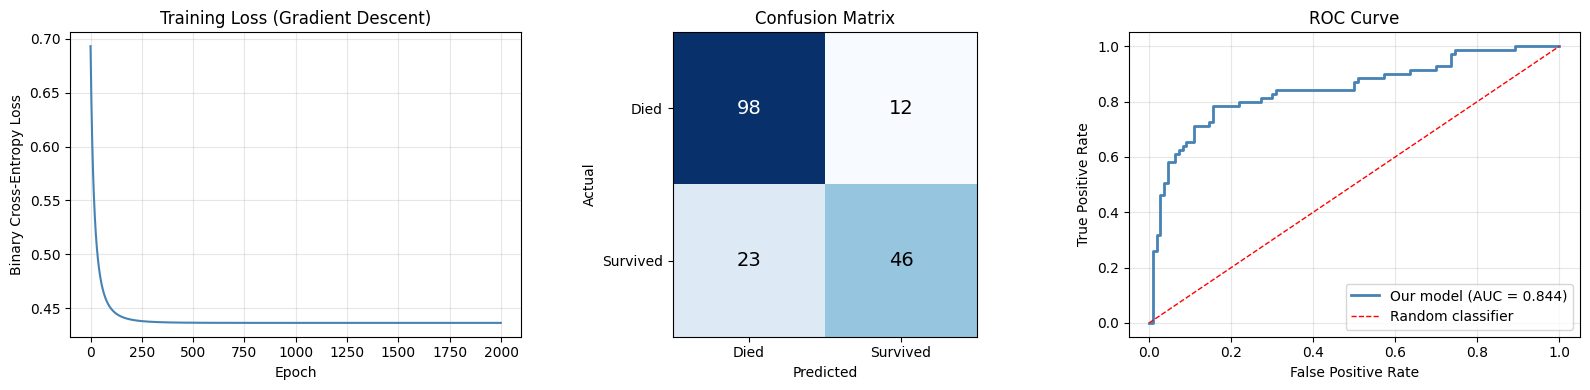

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Training loss curve ──────────────────────────────────────
axes[0].plot(train_losses, 'steelblue', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].set_title('Training Loss (Gradient Descent)')
axes[0].grid(True, alpha=0.3)

# ── Confusion matrix ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
axes[1].set_xticklabels(['Died','Survived'])
axes[1].set_yticklabels(['Died','Survived'])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i,j], ha='center', va='center',
                     color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)

# ── ROC Curve ────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[2].plot(fpr, tpr, 'steelblue', lw=2, label=f'Our model (AUC = {roc_auc:.3f})')
axes[2].plot([0,1],[0,1], 'r--', lw=1, label='Random classifier')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('titanic_results.png', dpi=120)
plt.show()

## 6. Feature Importance

Since features are standardised, the magnitude of each weight `w[i]` directly shows how much that feature influences the prediction.

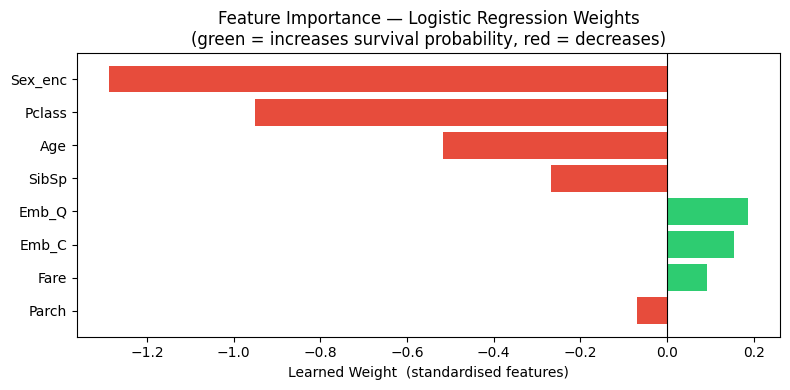

Feature    Weight
  Emb_Q  0.186661
  Emb_C  0.154041
   Fare  0.092112
  Parch -0.069713
  SibSp -0.268251
    Age -0.516036
 Pclass -0.951144
Sex_enc -1.287851


In [10]:
importance = pd.DataFrame({'Feature': features, 'Weight': w})
importance = importance.reindex(importance['Weight'].abs().sort_values(ascending=True).index)

plt.figure(figsize=(8, 4))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in importance['Weight']]
plt.barh(importance['Feature'], importance['Weight'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Learned Weight  (standardised features)')
plt.title('Feature Importance — Logistic Regression Weights\n(green = increases survival probability, red = decreases)')
plt.tight_layout()
plt.savefig('titanic_weights.png', dpi=120)
plt.show()

print(importance.sort_values('Weight', ascending=False).to_string(index=False))

## 7. Predict on a New Passenger

Demonstrate the full **inference pipeline**: raw input → preprocess → sigmoid → probability.

In [11]:
def predict_passenger(pclass, sex, age, sibsp, parch, fare, embarked, w, b, scaler, features):
    sex_enc = 1 if sex == 'male' else 0
    emb_c   = 1 if embarked == 'C' else 0
    emb_q   = 1 if embarked == 'Q' else 0

    x_raw = np.array([[pclass, sex_enc, age, sibsp, parch, fare, emb_c, emb_q]])
    x_std = scaler.transform(x_raw)

    z       = x_std @ w + b          # linear combination
    y_hat   = sigmoid(z)[0]           # σ(z)
    outcome = 'SURVIVED' if y_hat >= 0.5 else 'DIED'

    print(f"  z = w·x + b = {z[0]:.3f}")
    print(f"  ŷ = σ({z[0]:.3f}) = {y_hat:.4f}")
    print(f"  Prediction: {outcome}  (P(survive) = {y_hat:.2%})")
    return y_hat


print("── Rose (1st class, female, age 17) ──")
predict_passenger(1, 'female', 17, 0, 0, 100, 'C', w, b, scaler, features)

print()
print("── Jack (3rd class, male, age 20) ──")
predict_passenger(3, 'male', 20, 0, 0, 8, 'S', w, b, scaler, features)

── Rose (1st class, female, age 17) ──
  z = w·x + b = 3.608
  ŷ = σ(3.608) = 0.9736
  Prediction: SURVIVED  (P(survive) = 97.36%)

── Jack (3rd class, male, age 20) ──
  z = w·x + b = -2.051
  ŷ = σ(-2.051) = 0.1140
  Prediction: DIED  (P(survive) = 11.40%)


np.float64(0.11397079722603556)

## 8. Comparison with sklearn's LogisticRegression

Verify our from-scratch implementation produces competitive results.

In [12]:
from sklearn.linear_model import LogisticRegression

sk_model = LogisticRegression(max_iter=2000, random_state=42)
sk_model.fit(X_train, y_train)

sk_acc = sk_model.score(X_test, y_test)
sk_auc = roc_auc_score(y_test, sk_model.predict_proba(X_test)[:,1])

print("─────────────────────────────────────────")
print(f"  Our implementation  — Acc: {test_acc:.4f}  AUC: {roc_auc:.4f}")
print(f"  sklearn              — Acc: {sk_acc:.4f}  AUC: {sk_auc:.4f}")
print("─────────────────────────────────────────")

─────────────────────────────────────────
  Our implementation  — Acc: 0.8045  AUC: 0.8437
  sklearn              — Acc: 0.8045  AUC: 0.8436
─────────────────────────────────────────
